# Fixed Brain Tumor MRI Preprocessing Notebook

This notebook fixes the common Kaggle path error by using a robust path resolver:

1. It first tries your previous mounted paths:
   - `/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset`
   - `/kaggle/input/datasets/ishans24/brain-tumor-dataset`
   - `/kaggle/input/datasets/alamshihab075/brain-tumor-mri-dataset-for-deep-learning`
2. If any path is missing, it falls back to `kagglehub.dataset_download()`.
3. It preprocesses every image to RGB, 224 × 224, PNG.
4. It hashes the **preprocessed pixel array** to detect duplicates.
5. It combines **Masoud + Ishans24** into train/validation/internal-test.
6. It keeps **Alamshihab075** only for external validation after removing duplicates with the internal pool.

Final output:

```text
/kaggle/working/final_brain_tumor_preprocessed_dataset
```

Recommended usage in Kaggle:

- Run this notebook first.
- Then use the output folder in your model-training notebook.

## 1. Imports and configuration

In [ ]:
import os
import shutil
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

SEED = 42
np.random.seed(SEED)

IMG_SIZE = (224, 224)
CANONICAL_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")

################################
###    CHANGE THIS BASED ON YOUR PATH. The rest should be fine
MAIN_DIRECTORY = "/Users/simonwilliams/code/simonwilliams32/MRI_project"
###


WORKING_DIR = os.path.join(MAIN_DIRECTORY, "raw_data")
PREPROCESSED_DIR = os.path.join(WORKING_DIR, "preprocessed_all_brain_tumor_images")
FINAL_DATASET_DIR = os.path.join(WORKING_DIR, "final_brain_tumor_preprocessed_dataset")
REPORT_DIR = os.path.join(WORKING_DIR, "preprocessing_reports")

os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Configuration ready.")
print("Image size:", IMG_SIZE)
print("Final dataset directory:", FINAL_DATASET_DIR)

Configuration ready.
Image size: (224, 224)
Final dataset directory: /Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


## 2. Resolve dataset paths safely

In [ ]:
import os

RAW_DATA_DIR = os.path.join(os.getcwd(), "raw_data")

dataset_paths = {
    "Masoud": os.path.join(RAW_DATA_DIR, "brain-tumor-mri-dataset"),
    "Ishans24": os.path.join(RAW_DATA_DIR, "brain-tumor-dataset"),
    "Alamshihab075": os.path.join(RAW_DATA_DIR, "brain-tumor-mri-dataset-for-deep-learning"),
}


## 3. Class-name normalization

In [ ]:
class_aliases = {
    "glioma": "glioma",
    "glioma tumor": "glioma",
    "glioma tumour": "glioma",
    "glioma_tumor": "glioma",
    "glioma-tumor": "glioma",
    "meningioma": "meningioma",
    "meningioma tumor": "meningioma",
    "meningioma tumour": "meningioma",
    "meningioma_tumor": "meningioma",
    "meningioma-tumor": "meningioma",
    "pituitary": "pituitary",
    "pituitary tumor": "pituitary",
    "pituitary tumour": "pituitary",
    "pituitary_tumor": "pituitary",
    "pituitary-tumor": "pituitary",
    "notumor": "notumor",
    "no tumor": "notumor",
    "no tumour": "notumor",
    "no_tumor": "notumor",
    "no-tumor": "notumor",
    "normal": "notumor",
    "non tumor": "notumor",
    "non_tumor": "notumor",
    "non-tumor": "notumor",
}


def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("_", " ").replace("-", " ")
    text = " ".join(text.split())
    return text


def detect_class_from_path(path):
    for part in Path(path).parts:
        normalized = normalize_text(part)
        if normalized in class_aliases:
            return class_aliases[normalized]
    return None

## 4. Collect image paths

In [ ]:
def collect_images(dataset_name, dataset_path):
    rows = []
    skipped_unknown_class = 0

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if not file.lower().endswith(IMAGE_EXTS):
                continue

            image_path = os.path.join(root, file)
            detected_class = detect_class_from_path(image_path)

            if detected_class is None:
                skipped_unknown_class += 1
                continue

            rows.append({
                "Dataset": dataset_name,
                "Original Path": image_path,
                "Class": detected_class,
                "Original Filename": file,
                "Original Relative Path": os.path.relpath(image_path, dataset_path),
                "Original Folder": os.path.relpath(root, dataset_path),
                "Original Extension": Path(file).suffix.lower(),
            })

    return rows, skipped_unknown_class


all_rows = []
skipped_summary = []

for dataset_name, dataset_path in dataset_paths.items():
    rows, skipped = collect_images(dataset_name, dataset_path)
    print(f"{dataset_name}: found {len(rows)} class-detected images; skipped {skipped} unknown-class images.")
    all_rows.extend(rows)
    skipped_summary.append({
        "Dataset": dataset_name,
        "Detected Images": len(rows),
        "Skipped Unknown Class": skipped,
    })

raw_df = pd.DataFrame(all_rows)

if raw_df.empty:
    raise ValueError("No images were detected. Check folder structure and class mappings.")

display(pd.DataFrame(skipped_summary))
print("Total detected images:", len(raw_df))
display(raw_df.head())

raw_counts = (
    raw_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Raw Image Count")
    .sort_values(["Dataset", "Class"])
)

display(raw_counts)

raw_df.to_csv(os.path.join(REPORT_DIR, "01_raw_detected_images.csv"), index=False)
raw_counts.to_csv(os.path.join(REPORT_DIR, "02_raw_class_counts.csv"), index=False)

Masoud: found 7200 class-detected images; skipped 0 unknown-class images.
Ishans24: found 10560 class-detected images; skipped 0 unknown-class images.
Alamshihab075: found 9257 class-detected images; skipped 0 unknown-class images.


,Dataset,Detected Images,Skipped Unknown Class
0,Masoud,7200,0
1,Ishans24,10560,0
2,Alamshihab075,9257,0


Total detected images: 27017


,Dataset,Original Path,Class,Original Filename,Original Relative Path,Original Folder,Original Extension
0,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,pituitary,Tr-pi_766.jpg,Training/pituitary/Tr-pi_766.jpg,Training/pituitary,.jpg
1,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,pituitary,Tr-pi_1169.jpg,Training/pituitary/Tr-pi_1169.jpg,Training/pituitary,.jpg
2,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,pituitary,Tr-pi_772.jpg,Training/pituitary/Tr-pi_772.jpg,Training/pituitary,.jpg
3,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,pituitary,Tr-pi_982.jpg,Training/pituitary/Tr-pi_982.jpg,Training/pituitary,.jpg
4,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,pituitary,Tr-pi_1141.jpg,Training/pituitary/Tr-pi_1141.jpg,Training/pituitary,.jpg


,Dataset,Class,Raw Image Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 5. Show raw samples

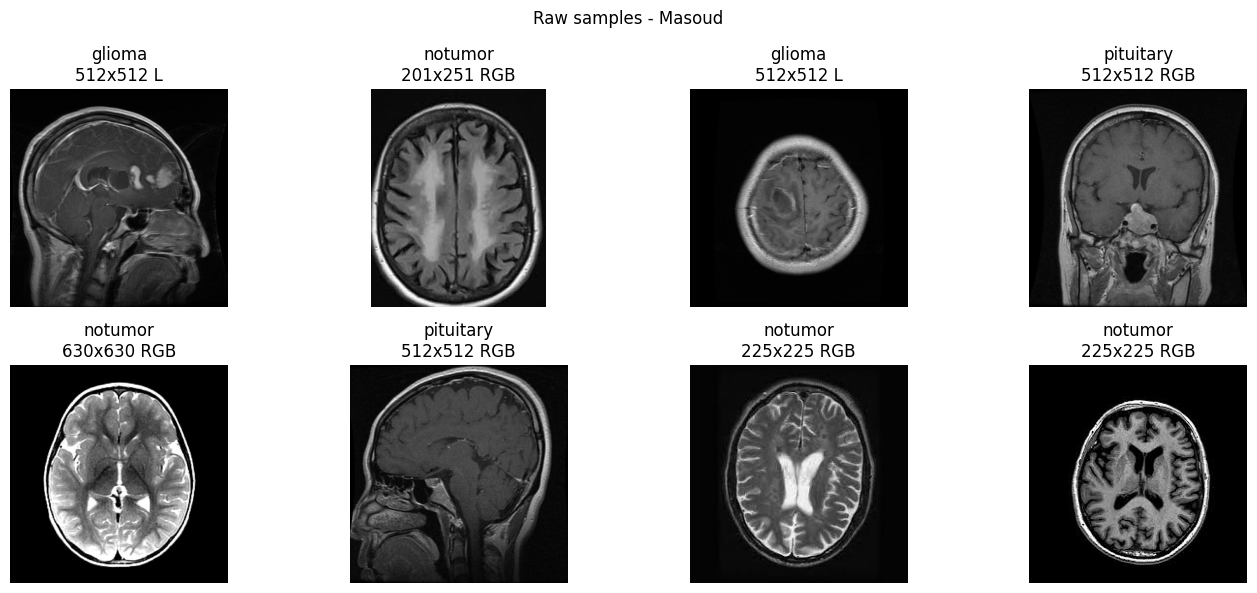

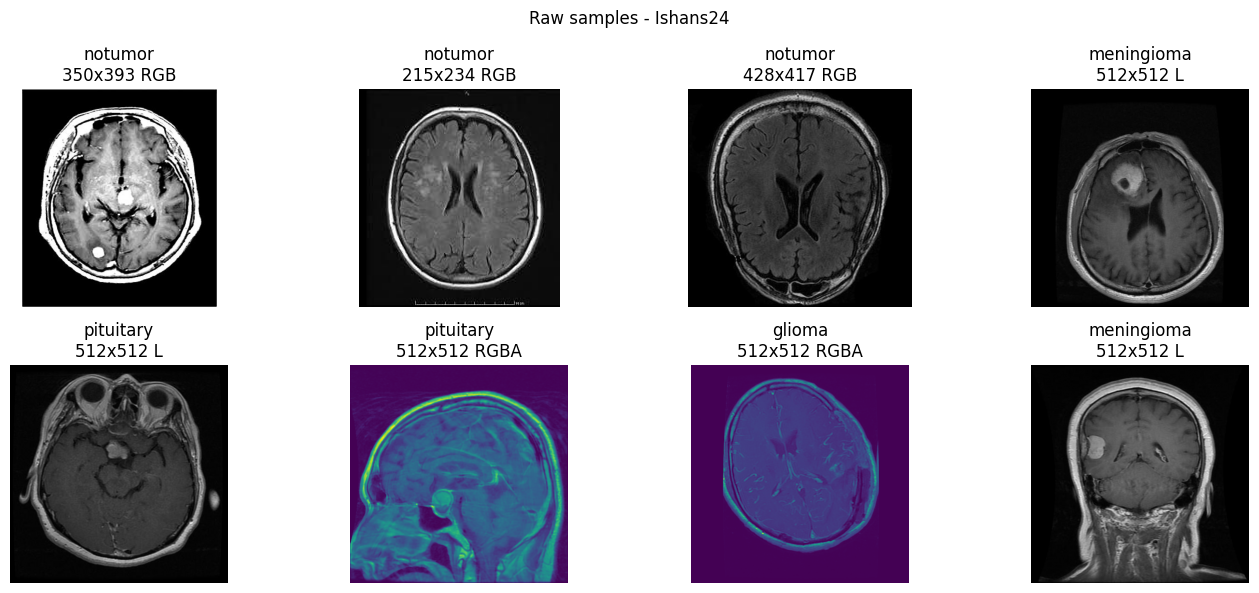

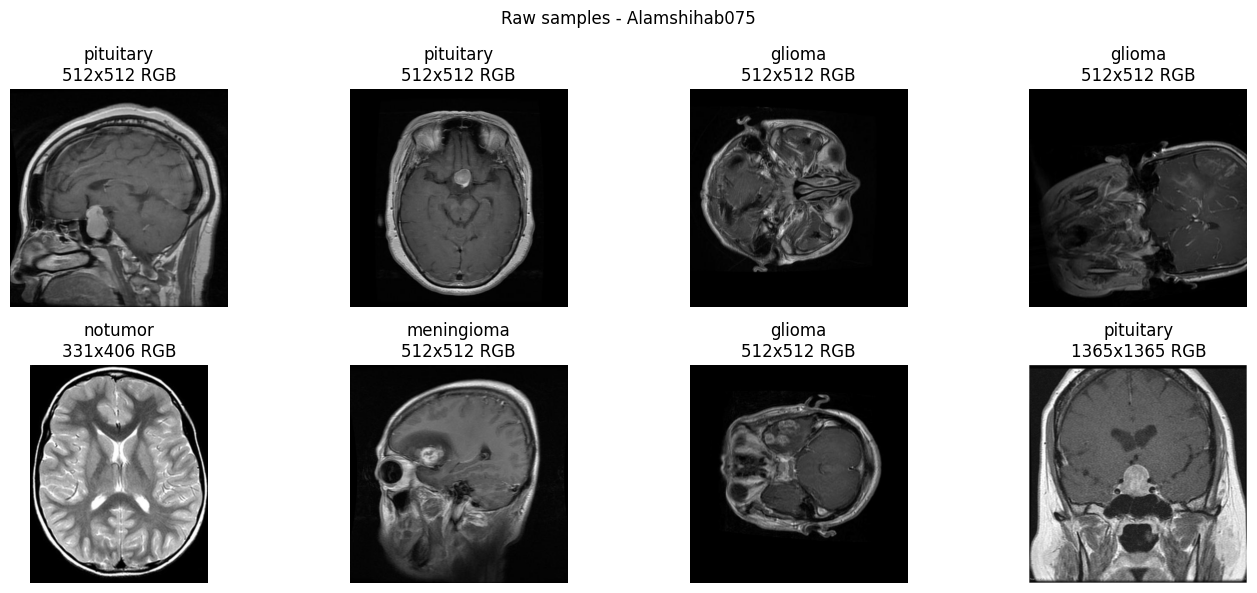

In [ ]:
def show_raw_samples(dataset_name, n=8):
    temp_df = raw_df[raw_df["Dataset"] == dataset_name]
    if temp_df.empty:
        print("No images for", dataset_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row["Original Path"])
            plt.subplot(2, 4, i + 1)
            plt.imshow(img, cmap="gray")
            plt.title(f"{row['Class']}\n{img.size[0]}x{img.size[1]} {img.mode}")
            plt.axis("off")
        except Exception as e:
            print("Could not open:", row["Original Path"], e)

    plt.suptitle(f"Raw samples - {dataset_name}")
    plt.tight_layout()
    plt.show()


for name in dataset_paths.keys():
    show_raw_samples(name, n=8)

## 6. Preprocess every image and hash preprocessed pixels

In [ ]:
def reset_directory(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


# Reset preprocessing output to avoid mixing old and new runs.
reset_directory(PREPROCESSED_DIR)

try:
    RESAMPLE_FILTER = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE_FILTER = Image.LANCZOS


def preprocess_image(image_path, img_size=IMG_SIZE):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(img_size, RESAMPLE_FILTER)
    return img


def hash_preprocessed_image(img):
    arr = np.asarray(img)
    return hashlib.md5(arr.tobytes()).hexdigest()


processed_rows = []
failed_rows = []

total_images = len(raw_df)
for idx, row in raw_df.reset_index(drop=True).iterrows():
    dataset_name = row["Dataset"]
    class_name = row["Class"]
    original_path = row["Original Path"]

    try:
        img = preprocess_image(original_path, img_size=IMG_SIZE)
        img_hash = hash_preprocessed_image(img)

        save_dir = os.path.join(PREPROCESSED_DIR, dataset_name, class_name)
        os.makedirs(save_dir, exist_ok=True)

        save_filename = f"{dataset_name}_{idx:06d}_{img_hash}.png"
        save_path = os.path.join(save_dir, save_filename)
        img.save(save_path, format="PNG")

        processed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Original Relative Path": row["Original Relative Path"],
            "Processed Path": save_path,
            "Preprocessed Hash": img_hash,
            "Width": IMG_SIZE[0],
            "Height": IMG_SIZE[1],
            "Mode": "RGB",
        })
    except Exception as e:
        failed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Error": str(e),
        })

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_images:
        print(f"Processed {idx + 1}/{total_images} images...")

processed_df = pd.DataFrame(processed_rows)
failed_df = pd.DataFrame(failed_rows)

if processed_df.empty:
    raise ValueError("All preprocessing failed; no processed images were created.")

print("Total preprocessed images:", len(processed_df))
print("Failed images:", len(failed_df))

display(processed_df.head())

processed_counts = (
    processed_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Preprocessed Count")
    .sort_values(["Dataset", "Class"])
)

display(processed_counts)

processed_df.to_csv(os.path.join(REPORT_DIR, "03_preprocessed_images.csv"), index=False)
processed_counts.to_csv(os.path.join(REPORT_DIR, "04_preprocessed_class_counts.csv"), index=False)
failed_df.to_csv(os.path.join(REPORT_DIR, "05_failed_preprocessing.csv"), index=False)

Processed 2000/27017 images...
Processed 4000/27017 images...
Processed 6000/27017 images...
Processed 8000/27017 images...
Processed 10000/27017 images...
Processed 12000/27017 images...
Processed 14000/27017 images...
Processed 16000/27017 images...
Processed 18000/27017 images...
Processed 20000/27017 images...
Processed 22000/27017 images...
Processed 24000/27017 images...
Processed 26000/27017 images...
Processed 27017/27017 images...
Total preprocessed images: 27017
Failed images: 0


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Masoud,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/pituitary/Tr-pi_766.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,b6fdb0a513678645b28bff819834fe27,224,224,RGB
1,Masoud,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/pituitary/Tr-pi_1169.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,c75ab73798ef17c4a6d2b9d437bcb19c,224,224,RGB
2,Masoud,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/pituitary/Tr-pi_772.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,e048877a2d0d08777a9f141686204cd0,224,224,RGB
3,Masoud,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/pituitary/Tr-pi_982.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,2dec1b7388f31da609e7fa2ab765a4e3,224,224,RGB
4,Masoud,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/pituitary/Tr-pi_1141.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,a74e542bd81af066060adabf2ca06a1f,224,224,RGB


,Dataset,Class,Preprocessed Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 7. Find duplicates after preprocessing

In [ ]:
duplicate_df = (
    processed_df.groupby("Preprocessed Hash")
    .filter(lambda x: len(x) > 1)
    .sort_values(["Preprocessed Hash", "Dataset", "Class"])
    .reset_index(drop=True)
)

if duplicate_df.empty:
    duplicate_hash_summary_df = pd.DataFrame(columns=[
        "Preprocessed Hash", "Duplicate_Entries", "Number_of_Datasets", "Classes", "Datasets"
    ])
    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df.copy()
else:
    duplicate_hash_summary_df = (
        duplicate_df.groupby("Preprocessed Hash")
        .agg(
            Duplicate_Entries=("Preprocessed Hash", "size"),
            Number_of_Datasets=("Dataset", "nunique"),
            Classes=("Class", lambda x: ", ".join(sorted(set(x)))),
            Datasets=("Dataset", lambda x: ", ".join(sorted(set(x)))),
        )
        .reset_index()
        .sort_values(["Number_of_Datasets", "Duplicate_Entries"], ascending=False)
    )

    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df[
        duplicate_hash_summary_df["Number_of_Datasets"] > 1
    ].copy()

print("Duplicate image entries after preprocessing:", len(duplicate_df))
print("Duplicate hash groups:", duplicate_df["Preprocessed Hash"].nunique() if not duplicate_df.empty else 0)
print("Duplicate hash groups appearing in more than one dataset:", len(cross_dataset_duplicate_hashes_df))

display(duplicate_df.head(100))
display(cross_dataset_duplicate_hashes_df.head(100))

duplicate_df.to_csv(os.path.join(REPORT_DIR, "06_duplicate_entries_after_preprocessing.csv"), index=False)
duplicate_hash_summary_df.to_csv(os.path.join(REPORT_DIR, "07_duplicate_hash_summary.csv"), index=False)
cross_dataset_duplicate_hashes_df.to_csv(os.path.join(REPORT_DIR, "08_cross_dataset_duplicate_hashes.csv"), index=False)

Duplicate image entries after preprocessing: 19590
Duplicate hash groups: 7175
Duplicate hash groups appearing in more than one dataset: 7175


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Alamshihab075,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,test/test/Pituitary/images/Tr-pi_0532.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,000296ed3f14282e340765e5d7b24227,224,224,RGB
1,Alamshihab075,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Train/Train/Pituitary/images/p (584).jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,000296ed3f14282e340765e5d7b24227,224,224,RGB
2,Ishans24,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,pituitary/pituitary1165.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,000296ed3f14282e340765e5d7b24227,224,224,RGB
3,Masoud,pituitary,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/pituitary/Tr-pi_24.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,000296ed3f14282e340765e5d7b24227,224,224,RGB
4,Alamshihab075,meningioma,/Users/simonwilliams/code/simonwilliams32/MRI_...,Train/Train/Meningioma/images/m2 (22).jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,0004a762d764396f8f5518caf1640432,224,224,RGB
...,...,...,...,...,...,...,...,...,...
95,Ishans24,meningioma,/Users/simonwilliams/code/simonwilliams32/MRI_...,meningioma/meningioma827.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
96,Masoud,meningioma,/Users/simonwilliams/code/simonwilliams32/MRI_...,Training/meningioma/Tr-me_1133.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
97,Alamshihab075,meningioma,/Users/simonwilliams/code/simonwilliams32/MRI_...,Train/Train/Meningioma/images/m2 (55).jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB
98,Ishans24,meningioma,/Users/simonwilliams/code/simonwilliams32/MRI_...,meningioma/meningioma1065.jpg,/Users/simonwilliams/code/simonwilliams32/MRI_...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB


,Preprocessed Hash,Duplicate_Entries,Number_of_Datasets,Classes,Datasets
2082,4948cd41e195a81192b2c160952197ee,16,3,notumor,"Alamshihab075, Ishans24, Masoud"
1216,2ae817c198efa08837133cb845fd29b0,13,3,meningioma,"Alamshihab075, Ishans24, Masoud"
518,1210952b4e54f23ce1450e6c04f01211,12,3,notumor,"Alamshihab075, Ishans24, Masoud"
1473,344396fa3b3359533286e8bd1cd22bce,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
2448,55caee96126e665a1b54070e234359a0,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
...,...,...,...,...,...
5716,ca2fa9b233e253611aafd605053cb9b6,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
5864,cf5761e4ba32866383a43edb2a571647,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6080,d71bf2b41416468598fb73cb26909c79,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6188,db306467e793f4e4474e0f313370ec21,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"


## 8. Deduplicate Masoud + Ishans24 for internal train/validation/test

In [ ]:
internal_sources = ["Masoud", "Ishans24"]
internal_df = processed_df[processed_df["Dataset"].isin(internal_sources)].copy()

if internal_df.empty:
    raise ValueError("Internal pool is empty. Masoud and Ishans24 images were not found.")

source_priority = {"Masoud": 0, "Ishans24": 1}
internal_df["Source Priority"] = internal_df["Dataset"].map(source_priority)

internal_dedup_df = (
    internal_df.sort_values(["Preprocessed Hash", "Source Priority", "Dataset"])
    .drop_duplicates(subset=["Preprocessed Hash"], keep="first")
    .reset_index(drop=True)
)

print("Internal source images before deduplication:", len(internal_df))
print("Internal source images after deduplication:", len(internal_dedup_df))
print("Removed internal duplicates:", len(internal_df) - len(internal_dedup_df))

internal_dataset_class_counts = (
    internal_dedup_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Dataset", "Class"])
)
internal_class_counts = (
    internal_dedup_df.groupby("Class")
    .size()
    .reset_index(name="Count")
    .sort_values("Class")
)

display(internal_dataset_class_counts)
display(internal_class_counts)

internal_dedup_df.to_csv(os.path.join(REPORT_DIR, "09_internal_masoud_ishans24_deduplicated.csv"), index=False)
internal_class_counts.to_csv(os.path.join(REPORT_DIR, "10_internal_deduplicated_class_counts.csv"), index=False)

Internal source images before deduplication: 17760
Internal source images after deduplication: 10594
Removed internal duplicates: 7166


,Dataset,Class,Count
0,Ishans24,glioma,1959
1,Ishans24,meningioma,746
2,Ishans24,notumor,75
3,Ishans24,pituitary,936
4,Masoud,glioma,1779
5,Masoud,meningioma,1684
6,Masoud,notumor,1657
7,Masoud,pituitary,1758


,Class,Count
0,glioma,3738
1,meningioma,2430
2,notumor,1732
3,pituitary,2694


## 9. Deduplicate Alamshihab075 for external validation

In [ ]:
alam_df = processed_df[processed_df["Dataset"] == "Alamshihab075"].copy()

if alam_df.empty:
    print("WARNING: Alamshihab075 pool is empty. External validation will be empty.")
    external_dedup_df = alam_df.copy()
else:
    internal_hashes = set(internal_dedup_df["Preprocessed Hash"])

    # Remove duplicates inside Alamshihab075 first.
    alam_unique_df = (
        alam_df.drop_duplicates(subset=["Preprocessed Hash"], keep="first")
        .reset_index(drop=True)
    )

    # Remove any Alamshihab075 image that appears in the internal pool.
    external_dedup_df = alam_unique_df[
        ~alam_unique_df["Preprocessed Hash"].isin(internal_hashes)
    ].reset_index(drop=True)

    print("Alamshihab075 original preprocessed images:", len(alam_df))
    print("Alamshihab075 unique images:", len(alam_unique_df))
    print("Final external validation images:", len(external_dedup_df))
    print("Removed Alamshihab075 images duplicated with internal pool:", len(alam_unique_df) - len(external_dedup_df))

external_class_counts = (
    external_dedup_df.groupby("Class")
    .size()
    .reset_index(name="External Validation Count")
    .sort_values("Class")
)

display(external_class_counts)

external_dedup_df.to_csv(os.path.join(REPORT_DIR, "11_external_alamshihab075_deduplicated.csv"), index=False)
external_class_counts.to_csv(os.path.join(REPORT_DIR, "12_external_deduplicated_class_counts.csv"), index=False)

Alamshihab075 original preprocessed images: 9257
Alamshihab075 unique images: 7914
Final external validation images: 4008
Removed Alamshihab075 images duplicated with internal pool: 3906


,Class,External Validation Count
0,glioma,2004
1,meningioma,2004


## 10. Stratified split: train / validation / internal test

In [ ]:
if len(internal_dedup_df) == 0:
    raise ValueError("Internal deduplicated dataset is empty.")

class_counts = internal_dedup_df["Class"].value_counts()
print("Internal class counts before split:")
display(class_counts.to_frame("Count"))

if (class_counts < 3).any():
    raise ValueError("At least one class has fewer than 3 images, so stratified splitting is unsafe.")

train_val_df, internal_test_df = train_test_split(
    internal_dedup_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=internal_dedup_df["Class"],
)

val_adjusted_ratio = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_adjusted_ratio,
    random_state=SEED,
    stratify=train_val_df["Class"],
)

split_summary_rows = []
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", internal_test_df),
    ("external_val", external_dedup_df),
]:
    for class_name in CANONICAL_CLASSES:
        count = int((df["Class"] == class_name).sum()) if not df.empty else 0
        split_summary_rows.append({"Split": split_name, "Class": class_name, "Count": count})

split_summary_df = pd.DataFrame(split_summary_rows)

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Internal test:", len(internal_test_df))
print("External validation:", len(external_dedup_df))

display(split_summary_df)

train_df.to_csv(os.path.join(REPORT_DIR, "13_train_split.csv"), index=False)
val_df.to_csv(os.path.join(REPORT_DIR, "14_val_split.csv"), index=False)
internal_test_df.to_csv(os.path.join(REPORT_DIR, "15_internal_test_split.csv"), index=False)
split_summary_df.to_csv(os.path.join(REPORT_DIR, "16_final_split_class_counts.csv"), index=False)

Internal class counts before split:


,Count
Class,
glioma,3738
pituitary,2694
meningioma,2430
notumor,1732


Split sizes:
Train: 7415
Validation: 1589
Internal test: 1590
External validation: 4008


,Split,Class,Count
0,train,glioma,2616
1,train,meningioma,1701
2,train,notumor,1212
3,train,pituitary,1886
4,val,glioma,561
5,val,meningioma,364
6,val,notumor,260
7,val,pituitary,404
8,test,glioma,561
9,test,meningioma,365


## 11. Create final folder dataset

In [ ]:
reset_directory(FINAL_DATASET_DIR)

for split_name in ["train", "val", "test", "external_val"]:
    for class_name in CANONICAL_CLASSES:
        os.makedirs(os.path.join(FINAL_DATASET_DIR, split_name, class_name), exist_ok=True)


def copy_split_images(df, split_name):
    copied_rows = []
    if df.empty:
        return copied_rows

    for i, row in df.reset_index(drop=True).iterrows():
        src = row["Processed Path"]
        class_name = row["Class"]
        img_hash = row["Preprocessed Hash"]
        dataset_name = row["Dataset"]

        dst_filename = f"{split_name}_{dataset_name}_{i:06d}_{img_hash}.png"
        dst = os.path.join(FINAL_DATASET_DIR, split_name, class_name, dst_filename)
        shutil.copy2(src, dst)

        copied_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Dataset": dataset_name,
            "Source Processed Path": src,
            "Final Path": dst,
            "Preprocessed Hash": img_hash,
        })

    return copied_rows


final_copy_rows = []
final_copy_rows.extend(copy_split_images(train_df, "train"))
final_copy_rows.extend(copy_split_images(val_df, "val"))
final_copy_rows.extend(copy_split_images(internal_test_df, "test"))
final_copy_rows.extend(copy_split_images(external_dedup_df, "external_val"))

final_manifest_df = pd.DataFrame(final_copy_rows)

print("Final dataset created at:")
print(FINAL_DATASET_DIR)
display(final_manifest_df.head())

final_manifest_df.to_csv(os.path.join(REPORT_DIR, "17_final_dataset_manifest.csv"), index=False)

Final dataset created at:
/Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


,Split,Class,Dataset,Source Processed Path,Final Path,Preprocessed Hash
0,train,pituitary,Ishans24,/Users/simonwilliams/code/simonwilliams32/MRI_...,/Users/simonwilliams/code/simonwilliams32/MRI_...,1bb15d9a62ae98791b06f7745858a356
1,train,glioma,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,/Users/simonwilliams/code/simonwilliams32/MRI_...,1a18ef2b22044027a686ff45afb8caa5
2,train,meningioma,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,/Users/simonwilliams/code/simonwilliams32/MRI_...,414b0db119dcc6a7f3d88bd9e7683f49
3,train,pituitary,Ishans24,/Users/simonwilliams/code/simonwilliams32/MRI_...,/Users/simonwilliams/code/simonwilliams32/MRI_...,2f37397f374e82235b8467e971d2e239
4,train,pituitary,Masoud,/Users/simonwilliams/code/simonwilliams32/MRI_...,/Users/simonwilliams/code/simonwilliams32/MRI_...,ae459f0c67e6e2a3d8a3d77cb97dc6ae


## 12. Verify final dataset and check duplicate leakage

In [ ]:
def collect_final_images(final_dir):
    rows = []
    for split_name in ["train", "val", "test", "external_val"]:
        for class_name in CANONICAL_CLASSES:
            class_dir = os.path.join(final_dir, split_name, class_name)
            if not os.path.exists(class_dir):
                continue

            for file in os.listdir(class_dir):
                if not file.lower().endswith(".png"):
                    continue

                path = os.path.join(class_dir, file)
                try:
                    img = preprocess_image(path, img_size=IMG_SIZE)
                    img_hash = hash_preprocessed_image(img)
                except Exception as e:
                    print("Could not hash final image:", path, e)
                    img_hash = None

                rows.append({
                    "Split": split_name,
                    "Class": class_name,
                    "Path": path,
                    "Filename": file,
                    "Hash": img_hash,
                })
    return pd.DataFrame(rows)


final_check_df = collect_final_images(FINAL_DATASET_DIR)

print("Final total images:", len(final_check_df))

final_counts_df = (
    final_check_df.groupby(["Split", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Split", "Class"])
)

display(final_counts_df)

if final_check_df.empty:
    leakage_df = pd.DataFrame(columns=final_check_df.columns)
    within_split_duplicate_df = pd.DataFrame(columns=final_check_df.columns)
else:
    leakage_df = (
        final_check_df.groupby("Hash")
        .filter(lambda x: x["Split"].nunique() > 1)
        .sort_values(["Hash", "Split"])
        .reset_index(drop=True)
    )

    within_split_duplicate_df = (
        final_check_df.groupby(["Split", "Hash"])
        .filter(lambda x: len(x) > 1)
        .sort_values(["Split", "Hash"])
        .reset_index(drop=True)
    )

print("Duplicate leakage across train/val/test/external_val:", len(leakage_df))
if len(leakage_df) > 0:
    print("WARNING: Duplicate leakage found across splits.")
    display(leakage_df.head(100))
else:
    print("Good: no duplicate images across final splits.")

print("Duplicate entries within the same split:", len(within_split_duplicate_df))
if len(within_split_duplicate_df) > 0:
    display(within_split_duplicate_df.head(100))
else:
    print("Good: no duplicate entries within individual splits.")

final_check_df.to_csv(os.path.join(REPORT_DIR, "18_final_dataset_check.csv"), index=False)
final_counts_df.to_csv(os.path.join(REPORT_DIR, "19_final_dataset_counts.csv"), index=False)
leakage_df.to_csv(os.path.join(REPORT_DIR, "20_final_split_leakage_check.csv"), index=False)
within_split_duplicate_df.to_csv(os.path.join(REPORT_DIR, "21_final_within_split_duplicate_check.csv"), index=False)

Final total images: 14602


,Split,Class,Count
0,external_val,glioma,2004
1,external_val,meningioma,2004
2,test,glioma,561
3,test,meningioma,365
4,test,notumor,260
5,test,pituitary,404
6,train,glioma,2616
7,train,meningioma,1701
8,train,notumor,1212
9,train,pituitary,1886


Duplicate leakage across train/val/test/external_val: 0
Good: no duplicate images across final splits.
Duplicate entries within the same split: 0
Good: no duplicate entries within individual splits.


## 13. Plot final class distributions

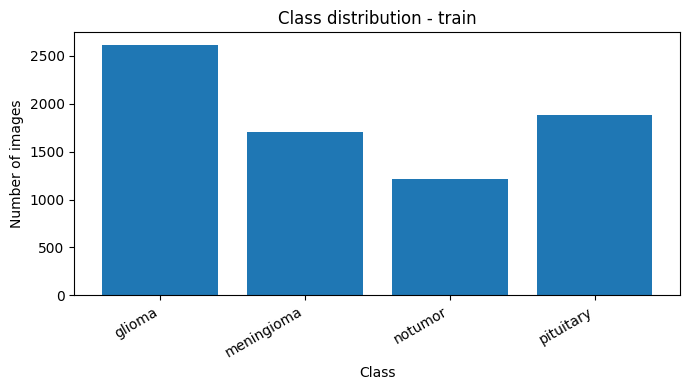

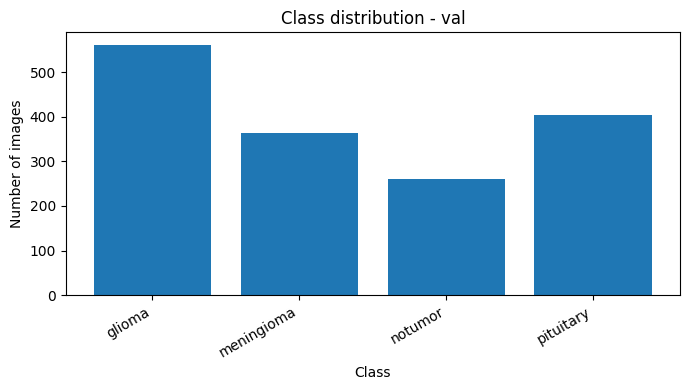

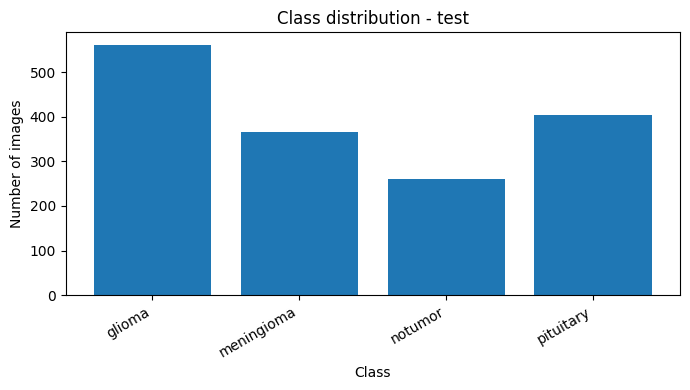

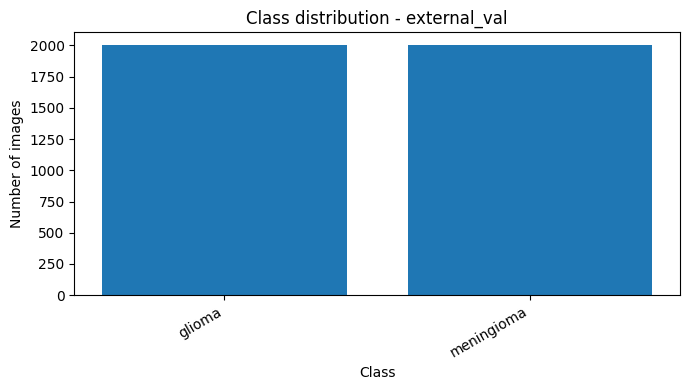

In [ ]:
for split_name in ["train", "val", "test", "external_val"]:
    temp_df = final_counts_df[final_counts_df["Split"] == split_name]
    plt.figure(figsize=(7, 4))
    plt.bar(temp_df["Class"], temp_df["Count"])
    plt.title(f"Class distribution - {split_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 14. Show final sample images

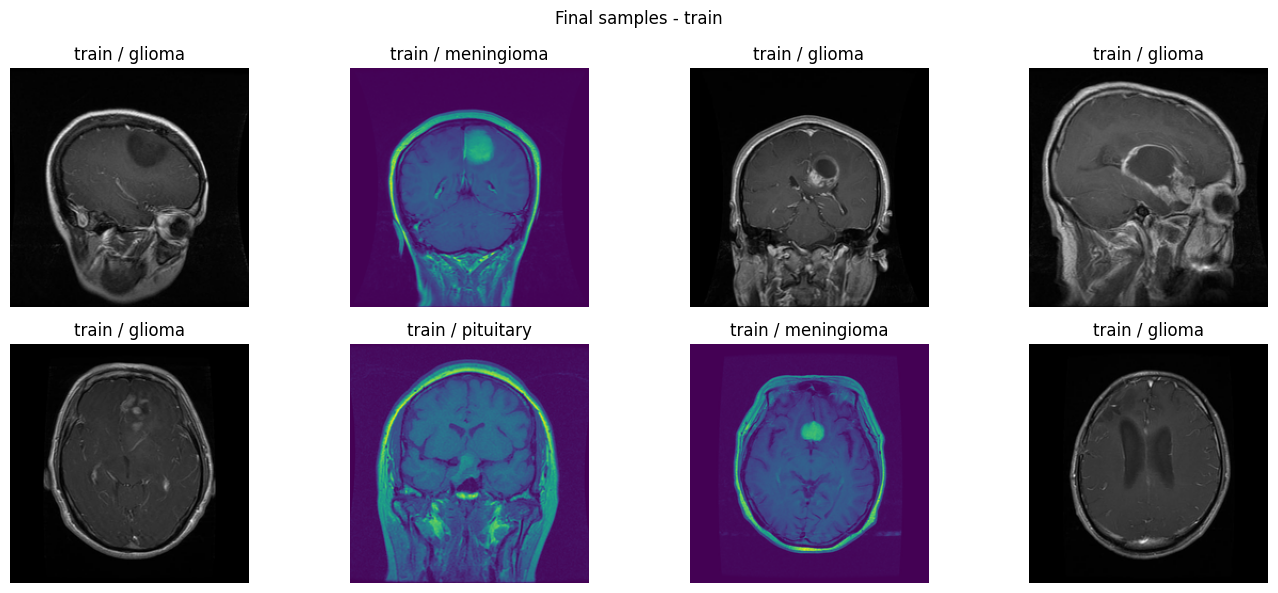

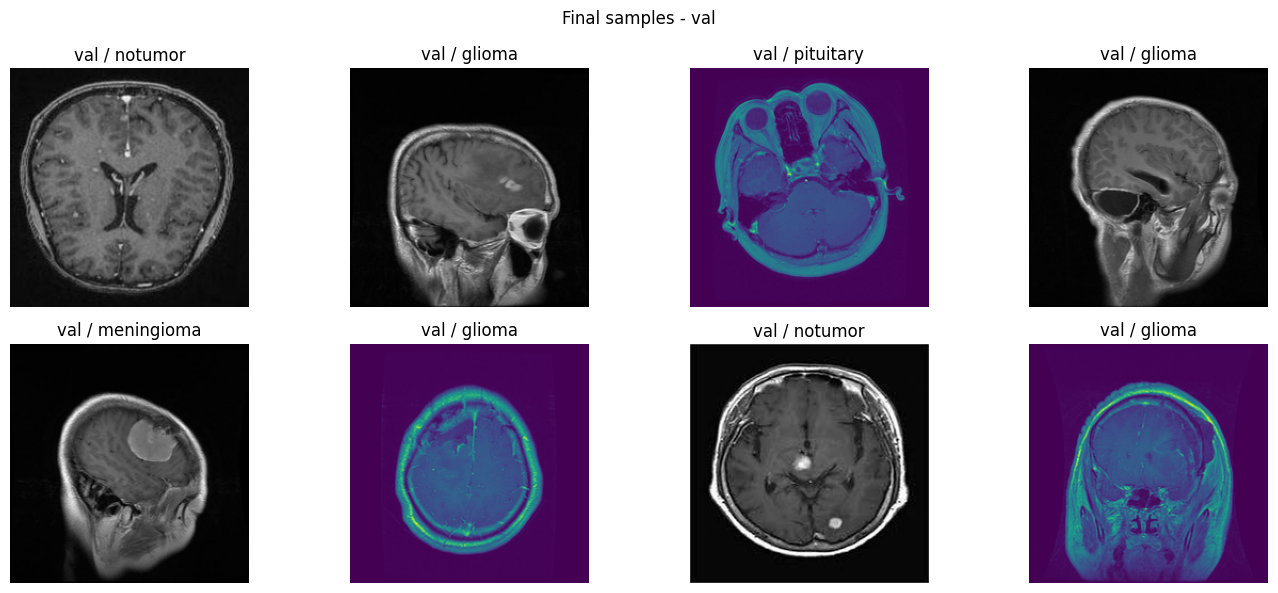

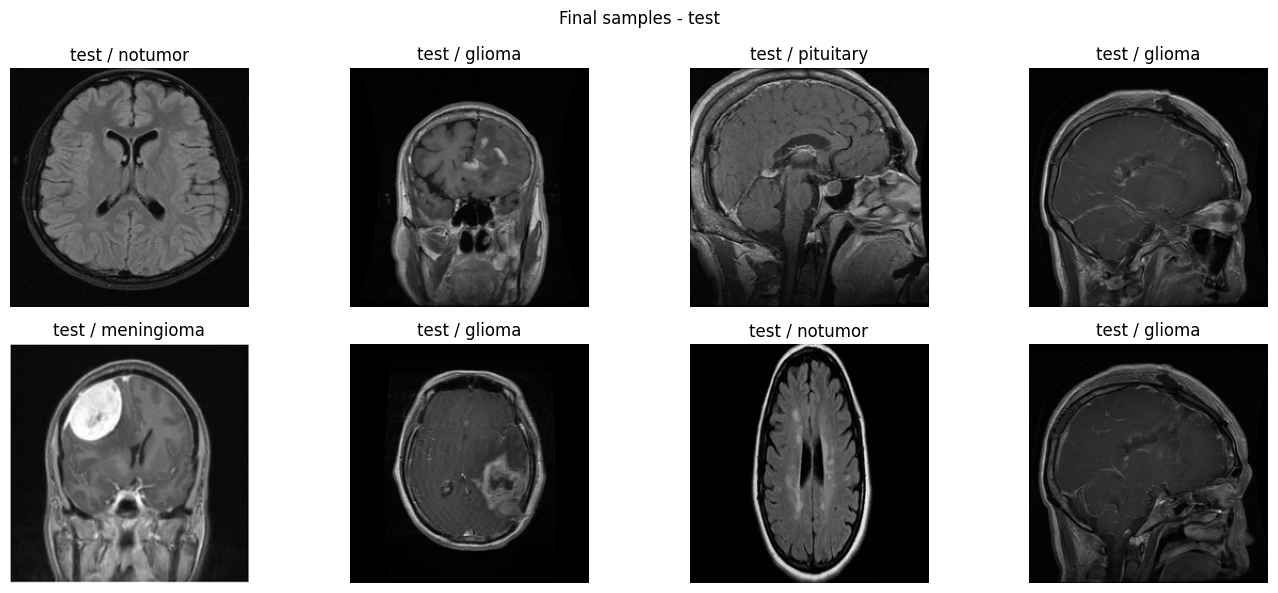

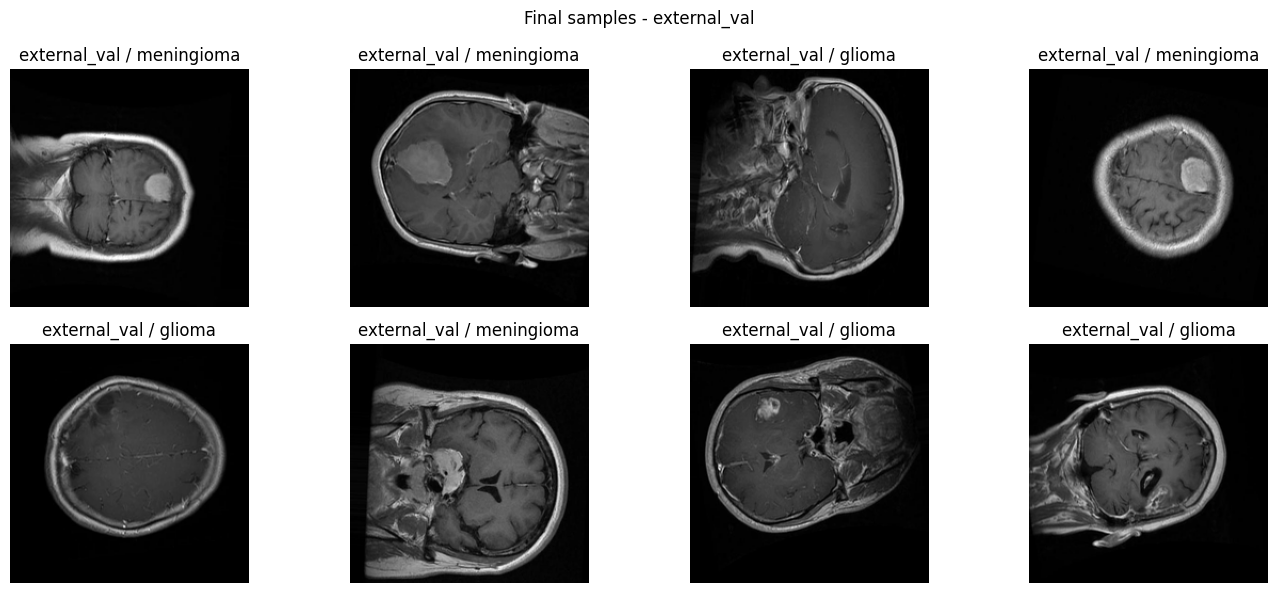

In [ ]:
def show_final_samples(split_name, n=8):
    temp_df = final_check_df[final_check_df["Split"] == split_name]
    if temp_df.empty:
        print("No images for split:", split_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["Path"])
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{row['Split']} / {row['Class']}")
        plt.axis("off")

    plt.suptitle(f"Final samples - {split_name}")
    plt.tight_layout()
    plt.show()


for split_name in ["train", "val", "test", "external_val"]:
    show_final_samples(split_name, n=8)

## 16. Use this output in your training notebook

In [ ]:
# Copy this block into your model-training notebook after this preprocessing notebook finishes.

FINAL_DATASET_DIR = "/Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset"

TRAIN_DIR = FINAL_DATASET_DIR + "/train"
VAL_DIR = FINAL_DATASET_DIR + "/val"
TEST_DIR = FINAL_DATASET_DIR + "/test"
EXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

import tensorflow as tf
train_ds = tf.keras.utils.image_dataset_from_directory(
     TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=True, class_names=class_names
 )
val_ds = tf.keras.utils.image_dataset_from_directory(
     VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )
test_ds = tf.keras.utils.image_dataset_from_directory(
     TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )
external_val_ds = tf.keras.utils.image_dataset_from_directory(
     EXTERNAL_VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
     label_mode="categorical", shuffle=False, class_names=class_names
 )
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
external_val_ds = external_val_ds.prefetch(AUTOTUNE)

print("Training paths prepared:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("EXTERNAL_VAL_DIR:", EXTERNAL_VAL_DIR)

Found 7415 files belonging to 4 classes.
Found 1589 files belonging to 4 classes.
Found 1590 files belonging to 4 classes.
Found 4008 files belonging to 4 classes.
Training paths prepared:
TRAIN_DIR: /Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/train
VAL_DIR: /Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/val
TEST_DIR: /Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/test
EXTERNAL_VAL_DIR: /Users/simonwilliams/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset/external_val


## Paper methodology text

You can use this in the preprocessing section:

> All images from the Masoud, Ishans24, and Alamshihab075 brain tumor MRI datasets were standardized to RGB format and resized to 224 × 224 pixels. MD5 hashes were computed from the standardized pixel arrays rather than from the original files, allowing duplicate detection after preprocessing. The Masoud and Ishans24 datasets were combined and deduplicated, then split using stratified sampling into training, validation, and internal testing subsets. The Alamshihab075 dataset was reserved only for external validation. Any Alamshihab075 image whose preprocessed hash matched the internal dataset was removed to reduce duplicate leakage.

In [ ]:
""" Scaling!  """

In [ ]:
#SCALING!
#Inspect Shape
images, labels = next(iter(train_ds))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Image dtype:", images.dtype)
print("\nFirst image shape:", images[0].shape)
print("First label:", labels[0])

Images shape: (32, 224, 224, 3)
Labels shape: (32, 4)
Image dtype: <dtype: 'float32'>

First image shape: (224, 224, 3)
First label: tf.Tensor([0. 0. 0. 1.], shape=(4,), dtype=float32)


In [ ]:
#check pixel values
for images, labels in train_ds.take(5):
    print(images.numpy().min(),
        images.numpy().max())

0.0 255.0
0.0 255.0
0.0 255.0
0.0 255.0
0.0 255.0


In [ ]:
#Scale down pixel values
train_ds_scaled = train_ds.map(lambda images, labels: (images / 255.0, labels))
val_ds_scaled = val_ds.map(lambda images, labels: (images / 255.0, labels))
test_ds_scaled = test_ds.map(lambda images, labels: (images / 255.0, labels))
external_val_ds_scaled = external_val_ds.map(lambda images, labels: (images / 255.0, labels))

In [ ]:
#Check that scaling has been done (shouls be between 0 and 1)
images, labels = next(iter(train_ds_scaled))
print(images.numpy().min())
print(images.numpy().max())
print(images.dtype)

0.0
1.0
<dtype: 'float32'>
